In [1]:
import numpy as np
import pandas as pd
import os
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.gridspec import GridSpec
from matplotlib.colors import TwoSlopeNorm, ListedColormap
from matplotlib.patches import Patch
import argparse
from mpl_toolkits.axes_grid1 import make_axes_locatable
import re

In [2]:
def significance_category(row, i):
    
    single_sig = row[f'sig{i}_95_single']
    multi_sig = row[f'sig{i}_95_multi']
    
    if single_sig and multi_sig:
        return 3       # Both
    elif single_sig:
        return 1       # Single only
    elif multi_sig:
        return 2       # Multi only
    else:
        return 0       # Neither

In [3]:
#%% set up path
path = r'/gpfs/work4/0/FWC2/Spatial_dependence/Disease_outbreak/global'
df_multi = pd.read_csv(os.path.join(path,'output/global/single_multi/res_aggregated_rates_global_multi_waterborne.csv'))
df_single = pd.read_csv(os.path.join(path,'output/global/single_multi/res_aggregated_rates_global_single_waterborne.csv'))  

In [4]:
df = df_single[['ISO'] + 
              [f't{i}' for i in range(13)] +
              [f'sig{i}_95' for i in range(13)] +
              [f'sig{i}_99' for i in range(13)]].merge(
    
    df_multi[['ISO'] + 
             [f't{i}' for i in range(13)] +
             [f'sig{i}_95' for i in range(13)] +
             [f'sig{i}_99' for i in range(13)]],
    
    on='ISO',
    suffixes=('_single', '_multi')
)
df = df.dropna(axis=0).reset_index(drop=True)

In [20]:
df

,ISO,t0_single,t1_single,t2_single,t3_single,t4_single,t5_single,t6_single,t7_single,t8_single,...,sig3_99_multi,sig4_99_multi,sig5_99_multi,sig6_99_multi,sig7_99_multi,sig8_99_multi,sig9_99_multi,sig10_99_multi,sig11_99_multi,sig12_99_multi
0,AFG,0.210526,0.210526,0.263158,0.263158,0.263158,0.263158,0.263158,0.263158,0.263158,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,AGO,0.131148,0.163934,0.163934,0.163934,0.163934,0.163934,0.163934,0.163934,0.163934,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,BDI,0.000000,0.076923,0.076923,0.230769,0.230769,0.230769,0.230769,0.230769,0.230769,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,BEN,0.000000,0.000000,0.000000,0.050000,0.050000,0.050000,0.050000,0.100000,0.100000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,BGD,0.090909,0.181818,0.181818,0.363636,0.363636,0.363636,0.454545,0.454545,0.454545,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,BOL,0.000000,0.000000,0.000000,0.185185,0.185185,0.259259,0.259259,0.259259,0.296296,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
6,BRA,0.050000,0.100000,0.100000,0.100000,0.250000,0.250000,0.250000,0.300000,0.300000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,CMR,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,0.055556,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,COD,0.028571,0.057143,0.085714,0.085714,0.114286,0.114286,0.171429,0.171429,0.171429,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,COG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# precursor rate difference
df0=df.copy()
for i in range(13):
    df0[f'diff{i}'] = (
        df0[f't{i}_multi'] -
        df0[f't{i}_single']
    )
df_diff = (df0.set_index('ISO')[
    [f'diff{i}' for i in range(12)]
].T)

df_diff.index = range(1, 13)

In [6]:
# significance category
df0=df.copy()
for i in range(13):
    df0[f'sig_cat{i}'] = df0.apply(
        lambda row: significance_category(row, i),
        axis=1
    )
df_sig = (df0.set_index('ISO')[
    [f'sig_cat{i}' for i in range(12)]
].T)    
df_sig.index = range(1, 13)

In [7]:
df_diff

ISO,AFG,AGO,BDI,BEN,BGD,BOL,BRA,CMR,COD,COG,...,SLV,SOM,SSD,TCD,TLS,TZA,UGA,YEM,ZMB,ZWE
1,-0.052632,-0.110739,0.000000,0.00,0.000000,0.000000,-0.050000,-0.055556,-0.028571,0.000000,...,0.000000,0.062500,0.000000,0.000000,0.000000,-0.073171,-0.058824,0.0,0.000000,0.000000
2,-0.052632,-0.143526,-0.076923,0.00,0.000000,0.148148,0.005263,-0.055556,-0.057143,0.142857,...,0.000000,0.003676,0.000000,0.000000,0.000000,-0.146341,0.018100,0.0,0.000000,0.000000
3,0.000000,-0.143526,-0.076923,0.00,0.090909,0.148148,0.110526,-0.055556,-0.085714,0.142857,...,-0.076923,0.066176,0.000000,0.000000,0.000000,-0.146341,0.036199,0.0,0.031250,-0.002976
4,0.210526,-0.143526,-0.230769,-0.05,0.000000,-0.037037,0.110526,-0.055556,-0.085714,0.142857,...,0.000000,0.066176,0.000000,0.000000,0.000000,-0.219512,0.036199,0.0,0.031250,-0.002976
5,0.210526,-0.143526,-0.230769,-0.05,0.090909,-0.037037,-0.039474,-0.055556,-0.114286,0.142857,...,-0.076923,0.007353,0.000000,0.000000,0.000000,-0.219512,0.036199,0.0,0.031250,-0.002976
6,0.210526,-0.143526,-0.230769,-0.05,0.090909,-0.074074,-0.039474,-0.055556,-0.114286,0.142857,...,-0.076923,0.069853,0.000000,0.000000,0.000000,-0.189209,0.036199,0.0,0.031250,-0.002976
7,0.210526,-0.143526,-0.230769,-0.05,0.000000,-0.074074,0.013158,-0.055556,-0.171429,0.142857,...,-0.153846,0.069853,-0.166667,0.100000,0.000000,-0.189209,0.054299,0.0,0.031250,-0.002976
8,0.210526,-0.143526,-0.230769,-0.10,0.000000,-0.074074,-0.036842,-0.055556,-0.171429,0.142857,...,-0.153846,0.069853,-0.166667,0.100000,0.000000,-0.189209,0.054299,0.0,0.031250,0.017857
9,0.210526,-0.143526,-0.230769,-0.10,0.000000,-0.111111,0.015789,-0.055556,-0.171429,0.142857,...,-0.153846,0.011029,-0.166667,0.100000,0.000000,-0.189209,0.054299,0.0,-0.020032,0.098214
10,0.315789,-0.176313,-0.307692,-0.10,0.000000,-0.148148,0.068421,-0.055556,-0.171429,0.142857,...,-0.153846,0.011029,-0.166667,0.100000,0.538462,-0.213599,0.131222,0.0,-0.096955,0.098214


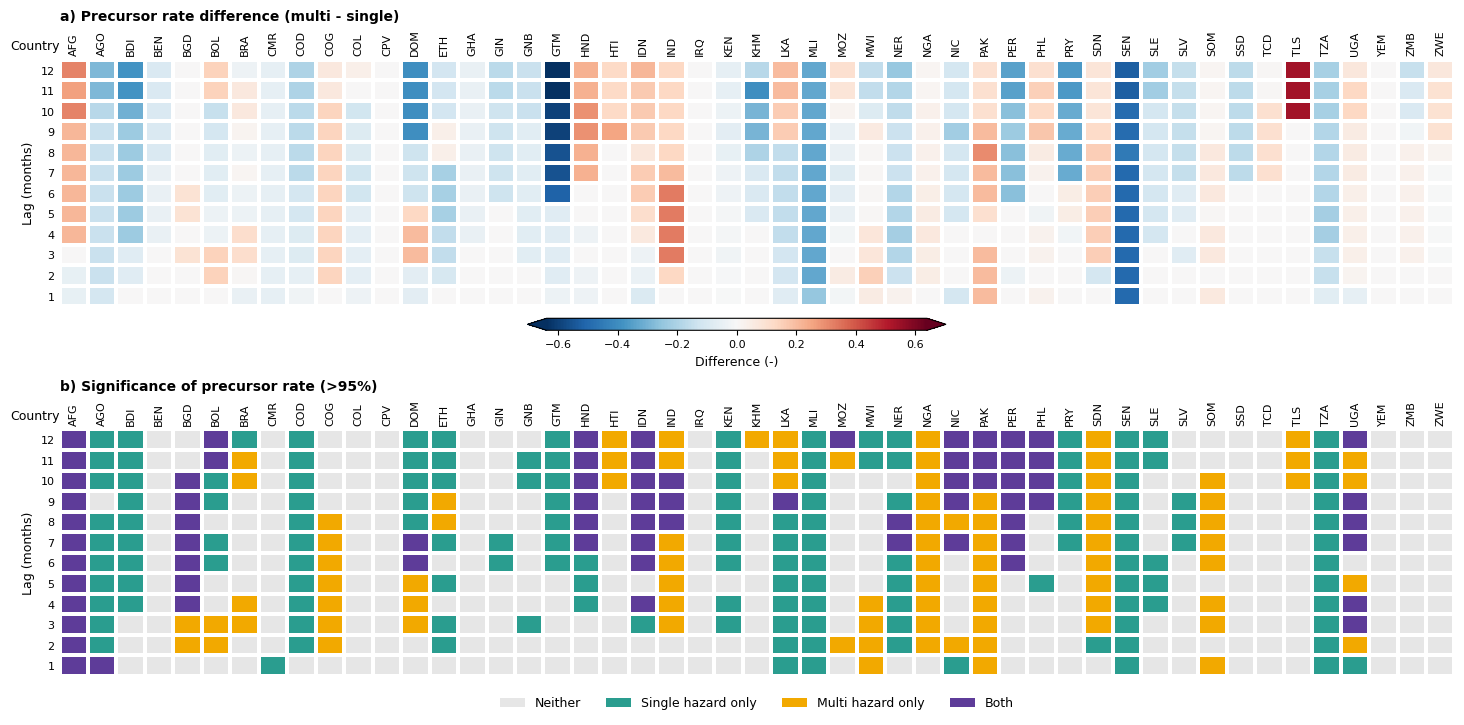

In [50]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(18, 8),
    gridspec_kw={
        'height_ratios': [1, 1],
        'hspace': 0.5
    }
)

# --------------------------------------------------
# A. Multi - single precursor rate
# --------------------------------------------------

ax = axes[0]

max_abs = np.nanmax(
    np.abs(df_diff.values)
)

norm = TwoSlopeNorm(
    vmin=-max_abs,
    vcenter=0,
    vmax=max_abs
)

im1 = ax.pcolormesh(
    df_diff.values,
    cmap='RdBu_r',
    norm=norm,
    edgecolors='white',
    linewidth=1.5,
    shading='flat'
)

# y axis = lag
ax.set_yticks(np.arange(12)+0.5)
ax.set_yticklabels(
    [f'{i}' for i in range(1, 13)],fontsize=8
)

ax.set_ylabel(
    'Lag (months)',
    fontsize=9
)

ax.set_title(
    'a) Precursor rate difference (multi - single)',
    loc='left',
    fontweight='bold',
    fontsize=10
)

ax.set_xticks(np.arange(len(df_diff.columns))+0.5)
ax.set_xticklabels(
    df_diff.columns,
    rotation=90,
    fontsize=8
)

ax.tick_params(
    axis='x',
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
    pad=3
)
ax.text(
    0, 1.03,
    'Country',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=9
)

# Colorbar
# cbar1 = fig.colorbar(
#     im1,
#     ax=ax,
#     orientation='horizontal',
#     pad=0.07,
#     shrink=0.3,      # shorter
#     aspect=50        # thinner
# )

# Get Panel A position
pos = ax.get_position()

# Colorbar: 50% width, centered
cax = fig.add_axes([
    pos.x0 + 0.26,
    pos.y0 - 0.03,
    0.30 * pos.width,
    0.015
])

cbar1 = fig.colorbar(
    im1,
    cax=cax,
    orientation='horizontal',
    extend='both'
)

cbar1.set_label(
    'Difference (-)',
    fontsize=9
)

cbar1.ax.tick_params(
    labelsize=8
)

######### signicance of precursor rate (>95%)
ax = axes[1]

# colors = ['#E6E6E6', '#4C78A8', '#F2A900', '#2A9D8F'] # gray, blue, yellow, green
# colors = ['#E6E6E6', '#2A9D8F', '#F2A900', '#b2182b'] # gray, green, yellow, red
# colors = ['#E6E6E6', '#2A9D8F', '#4C78A8', '#b2182b'] # gray, green, blue, red
# colors = ['#E6E6E6', '#2A9D8F', '#5e3c99', '#b2182b'] # gray, green, purple, red
colors = ['#E6E6E6', '#2A9D8F', '#F2A900', '#5e3c99'] # gray, green, yellow, purple

sig_cmap = ListedColormap(colors)

im2 = ax.pcolormesh(
    df_sig.values,
    cmap=sig_cmap,
    vmin=-0.5,
    vmax=3.5,
    edgecolors='white',
    linewidth=1.5,
    shading='flat'
)

ax.set_yticks(np.arange(12)+0.5)
ax.set_yticklabels(
    [f'{i}' for i in range(1, 13)],fontsize=8
)

ax.set_ylabel(
    'Lag (months)',
    fontsize=9
)

ax.set_title(
    'b) Significance of precursor rate (>95%)',
    loc='left',
    fontweight='bold',
    fontsize=10
)

ax.set_xticks(np.arange(len(df_diff.columns))+0.5)
ax.set_xticklabels(
    df_diff.columns,
    rotation=90,
    fontsize=8
)

ax.tick_params(
    axis='x',
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
    pad=3
)
ax.text(
    0, 1.03,
    'Country',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=9
)
# ============================================================
# Significance legend
# ============================================================

legend_elements = [
    Patch(
        facecolor=colors[0],
        label='Neither'
    ),
    Patch(
        facecolor=colors[1],
        label='Single hazard only'
    ),
    Patch(
        facecolor=colors[2],
        label='Multi hazard only'
    ),
    Patch(
        facecolor=colors[3],
        label='Both'
    )
]

ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.04),
    frameon=False,
    fontsize=9,
    ncol=4
)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(
        axis='both',
        which='both',
        length=0
    )

#save figure
outputdir = os.path.join(path, 'figures')
plt.savefig(os.path.join(outputdir, f'heatmap_single_multi_difference&significance.png'),
            dpi=450, bbox_inches='tight')